IDE synthetic data vs MG synthetic data

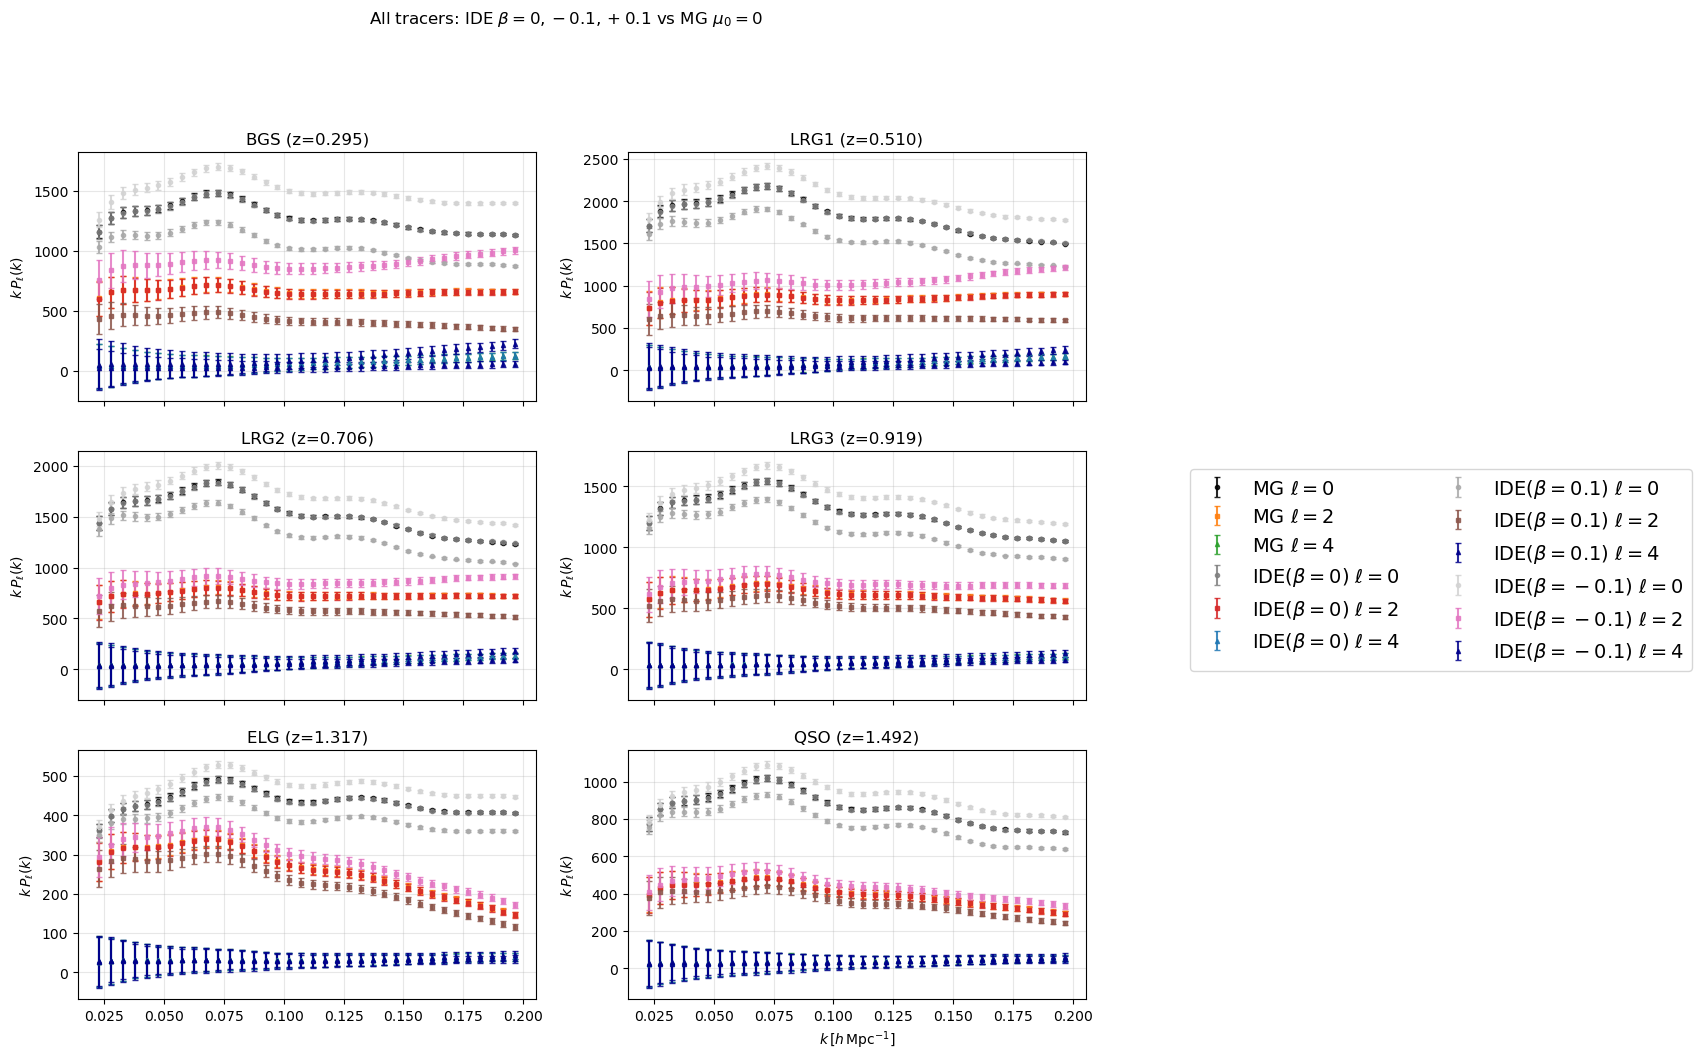

In [17]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt


from pathlib import Path

IDE_synthetic_data_dir = Path("/global/homes/n/nishavk/desilike/IDE/synthetic_data_IDE")
MG_synthetic_data_dir = Path("/global/homes/n/nishavk/desilike/MG/synthetic_data")
k_fixed = np.array([
    0.02271, 0.02768277, 0.03265554, 0.03762831, 0.04260109,
    0.04757386, 0.05254663, 0.05751940, 0.06249217, 0.06746494,
    0.07243771, 0.07741049, 0.08238326, 0.08735603, 0.09232880,
    0.09730157, 0.1022743,  0.1072471,  0.1122199,  0.1171927,
    0.1221654,  0.1271382,  0.1321110,  0.1370837,  0.1420565,
    0.1470293,  0.1520021,  0.1569748,  0.1619476,  0.1669204,
    0.1718931,  0.1768659,  0.1818387,  0.1868115,  0.1917842,
    0.1967570,
])

ells_plot = (0, 2, 4)


# Match synthetic-data tracer setup
tracer_settings = {
    "BGS":  {"z_pk": 0.295, "b1": 1.5, "b2": -0.5247206065},
    "LRG1": {"z_pk": 0.51,  "b1": 2.1, "b2": -0.9955559762},
    "LRG2": {"z_pk": 0.706, "b1": 2.1, "b2": -1.129586780},
    "LRG3": {"z_pk": 0.919, "b1": 2.1, "b2": -1.073936223},
    "ELG":  {"z_pk": 1.317, "b1": 1.2, "b2": 0.03376361031},
    "QSO":  {"z_pk": 1.492, "b1": 2.1, "b2": -0.7104953308},
}

fig, axs = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
axs = axs.flatten()

for i, (tracer, vals) in enumerate(tracer_settings.items()):
    
    # Load MG synthetic LCDM files
    k_MG = np.loadtxt(MG_synthetic_data_dir / f"{tracer}_LCDM_k.txt")
    P_MG = np.loadtxt(MG_synthetic_data_dir / f"{tracer}_LCDM_P0P2P4.txt")
    C_MG = np.loadtxt(MG_synthetic_data_dir / f"{tracer}_LCDM_cov.txt")
    
    # Load IDE synthetic LCDM files
    k_IDE_LCDM = np.loadtxt(IDE_synthetic_data_dir / f"{tracer}_LCDM_IDEModel1_k.txt")
    P_IDE_LCDM = np.loadtxt(IDE_synthetic_data_dir / f"{tracer}_LCDM_IDEModel1_P0P2P4.txt")
    C_IDE_LCDM = np.loadtxt(IDE_synthetic_data_dir / f"{tracer}_LCDM_IDEModel1_cov.txt")
    
    # Load IDE synthetic LCDM files
    k_IDE_POSBETA = np.loadtxt(IDE_synthetic_data_dir / f"{tracer}_IDEModel1POSBETA_IDEModel1_k.txt")
    P_IDE_POSBETA = np.loadtxt(IDE_synthetic_data_dir / f"{tracer}_IDEModel1POSBETA_IDEModel1_P0P2P4.txt")
    C_IDE_POSBETA = np.loadtxt(IDE_synthetic_data_dir / f"{tracer}_IDEModel1POSBETA_IDEModel1_cov.txt")
    
    # Load IDE synthetic LCDM files
    k_IDE_NEGBETA = np.loadtxt(IDE_synthetic_data_dir / f"{tracer}_IDEModel1NEGBETA_IDEModel1_k.txt")
    P_IDE_NEGBETA = np.loadtxt(IDE_synthetic_data_dir / f"{tracer}_IDEModel1NEGBETA_IDEModel1_P0P2P4.txt")
    C_IDE_NEGBETA = np.loadtxt(IDE_synthetic_data_dir / f"{tracer}_IDEModel1NEGBETA_IDEModel1_cov.txt")

    Nk_MG = k_MG.size
    if P_MG.size != 3 * Nk_MG:
        raise RuntimeError(f"{tracer}: P0P2P4 size mismatch ({P_MG.size} vs {3 * Nk_MG})")
    if C_MG.shape != (3 * Nk_MG, 3 * Nk_MG):
        raise RuntimeError(f"{tracer}: covariance shape mismatch {C_MG.shape}, expected {(3 * Nk_MG, 3 * Nk_MG)}")
    
    Nk_IDE_LCDM = k_IDE_LCDM.size
    if P_IDE_LCDM.size != 3 * Nk_IDE_LCDM:
        raise RuntimeError(f"{tracer}: P0P2P4 size mismatch ({P_IDE_LCDM.size} vs {3 * Nk_IDE_LCDM})")
    if C_IDE_LCDM.shape != (3 * Nk_IDE_LCDM, 3 * Nk_IDE_LCDM):
        raise RuntimeError(f"{tracer}: covariance shape mismatch {C_IDE_LCDM.shape}, expected {(3 * Nk_IDE_LCDM, 3 * Nk_IDE_LCDM)}")
    
    Nk_IDE_POSBETA = k_IDE_POSBETA.size
    if P_IDE_POSBETA.size != 3 * Nk_IDE_POSBETA:
        raise RuntimeError(f"{tracer}: P0P2P4 size mismatch ({P_IDE_POSBETA.size} vs {3 * Nk_IDE_POSBETA})")
    if C_IDE_POSBETA.shape != (3 * Nk_IDE_POSBETA, 3 * Nk_IDE_POSBETA):
        raise RuntimeError(f"{tracer}: covariance shape mismatch {C_IDE_POSBETA.shape}, expected {(3 * Nk_IDE_POSBETA, 3 * Nk_IDE_POSBETA)}")
    
    Nk_IDE_NEGBETA = k_IDE_NEGBETA.size
    if P_IDE_NEGBETA.size != 3 * Nk_IDE_NEGBETA:
        raise RuntimeError(f"{tracer}: P0P2P4 size mismatch ({P_IDE_NEGBETA.size} vs {3 * Nk_IDE_NEGBETA})")
    if C_IDE_NEGBETA.shape != (3 * Nk_IDE_NEGBETA, 3 * Nk_IDE_NEGBETA):
        raise RuntimeError(f"{tracer}: covariance shape mismatch {C_IDE_NEGBETA.shape}, expected {(3 * Nk_IDE_NEGBETA, 3 * Nk_IDE_NEGBETA)}")

    if not np.allclose(k_fixed, k_MG, rtol=0.0, atol=1e-12):
        max_dk = np.max(np.abs(k_fixed - k_MG))
        raise RuntimeError(f"{tracer}: k-grid mismatch (max |dk|={max_dk:.3e})")
    if not np.allclose(k_fixed, k_IDE_LCDM, rtol=0.0, atol=1e-12):
        max_dk = np.max(np.abs(k_fixed - k_IDE_LCDM))
        raise RuntimeError(f"{tracer}: k-grid mismatch (max |dk|={max_dk:.3e})")
    if not np.allclose(k_fixed, k_IDE_POSBETA, rtol=0.0, atol=1e-12):
        max_dk = np.max(np.abs(k_fixed - k_IDE_POSBETA))
        raise RuntimeError(f"{tracer}: k-grid mismatch (max |dk|={max_dk:.3e})")
    if not np.allclose(k_fixed, k_IDE_NEGBETA, rtol=0.0, atol=1e-12):
        max_dk = np.max(np.abs(k_fixed - k_IDE_NEGBETA))
        raise RuntimeError(f"{tracer}: k-grid mismatch (max |dk|={max_dk:.3e})")

    P0_MG = P_MG[0 * Nk_MG:1 * Nk_MG]
    P2_MG = P_MG[1 * Nk_MG:2 * Nk_MG]
    P4_MG = P_MG[2 * Nk_MG:3 * Nk_MG]
    
    P0_IDE_LCDM = P_IDE_LCDM[0 * Nk_IDE_LCDM:1 * Nk_IDE_LCDM]
    P2_IDE_LCDM = P_IDE_LCDM[1 * Nk_IDE_LCDM:2 * Nk_IDE_LCDM]
    P4_IDE_LCDM = P_IDE_LCDM[2 * Nk_IDE_LCDM:3 * Nk_IDE_LCDM]

    P0_IDE_POSBETA = P_IDE_POSBETA[0 * Nk_IDE_POSBETA:1 * Nk_IDE_POSBETA]
    P2_IDE_POSBETA = P_IDE_POSBETA[1 * Nk_IDE_POSBETA:2 * Nk_IDE_POSBETA]
    P4_IDE_POSBETA = P_IDE_POSBETA[2 * Nk_IDE_POSBETA:3 * Nk_IDE_POSBETA]
    
    P0_IDE_NEGBETA = P_IDE_NEGBETA[0 * Nk_IDE_NEGBETA:1 * Nk_IDE_NEGBETA]
    P2_IDE_NEGBETA = P_IDE_NEGBETA[1 * Nk_IDE_NEGBETA:2 * Nk_IDE_NEGBETA]
    P4_IDE_NEGBETA = P_IDE_NEGBETA[2 * Nk_IDE_NEGBETA:3 * Nk_IDE_NEGBETA]
    

    err0_MG = np.sqrt(np.diag(C_MG[0 * Nk_MG:1 * Nk_MG, 0 * Nk_MG:1 * Nk_MG]))
    err2_MG = np.sqrt(np.diag(C_MG[1 * Nk_MG:2 * Nk_MG, 1 * Nk_MG:2 * Nk_MG]))
    err4_MG = np.sqrt(np.diag(C_MG[2 * Nk_MG:3 * Nk_MG, 2 * Nk_MG:3 * Nk_MG]))

    err0_IDE_LCDM = np.sqrt(np.diag(C_IDE_LCDM[0 * Nk_IDE_LCDM:1 * Nk_IDE_LCDM, 0 * Nk_IDE_LCDM:1 * Nk_IDE_LCDM]))
    err2_IDE_LCDM = np.sqrt(np.diag(C_IDE_LCDM[1 * Nk_IDE_LCDM:2 * Nk_IDE_LCDM, 1 * Nk_IDE_LCDM:2 * Nk_IDE_LCDM]))
    err4_IDE_LCDM = np.sqrt(np.diag(C_IDE_LCDM[2 * Nk_IDE_LCDM:3 * Nk_IDE_LCDM, 2 * Nk_IDE_LCDM:3 * Nk_IDE_LCDM]))

    err0_IDE_POSBETA = np.sqrt(np.diag(C_IDE_POSBETA[0 * Nk_IDE_POSBETA:1 * Nk_IDE_POSBETA, 0 * Nk_IDE_POSBETA:1 * Nk_IDE_POSBETA]))
    err2_IDE_POSBETA = np.sqrt(np.diag(C_IDE_POSBETA[1 * Nk_IDE_POSBETA:2 * Nk_IDE_POSBETA, 1 * Nk_IDE_POSBETA:2 * Nk_IDE_POSBETA]))
    err4_IDE_POSBETA = np.sqrt(np.diag(C_IDE_POSBETA[2 * Nk_IDE_POSBETA:3 * Nk_IDE_POSBETA, 2 * Nk_IDE_POSBETA:3 * Nk_IDE_POSBETA]))
    
    err0_IDE_NEGBETA = np.sqrt(np.diag(C_IDE_NEGBETA[0 * Nk_IDE_NEGBETA:1 * Nk_IDE_NEGBETA, 0 * Nk_IDE_NEGBETA:1 * Nk_IDE_NEGBETA]))
    err2_IDE_NEGBETA = np.sqrt(np.diag(C_IDE_NEGBETA[1 * Nk_IDE_NEGBETA:2 * Nk_IDE_NEGBETA, 1 * Nk_IDE_NEGBETA:2 * Nk_IDE_NEGBETA]))
    err4_IDE_NEGBETA = np.sqrt(np.diag(C_IDE_NEGBETA[2 * Nk_IDE_NEGBETA:3 * Nk_IDE_NEGBETA, 2 * Nk_IDE_NEGBETA:3 * Nk_IDE_NEGBETA]))

    ax = axs[i]

    # Synthetic MG with covariance errors
    ax.errorbar(k_MG, k_MG * P0_MG, yerr=k_MG * err0_MG, fmt="o", ms=3, capsize=2,
                color="k", alpha=0.85, label=r"MG $\ell=0$")
    ax.errorbar(k_MG, k_MG * P2_MG, yerr=k_MG * err2_MG, fmt="s", ms=3, capsize=2,
                color="tab:orange", alpha=0.85, label=r"MG $\ell=2$")
    ax.errorbar(k_MG, k_MG * P4_MG, yerr=k_MG * err4_MG, fmt="^", ms=3, capsize=2,
                color="tab:green", alpha=0.85, label=r"MG $\ell=4$")
    
    # Synthetic IDE with covariance errors
    ax.errorbar(k_IDE_LCDM, k_IDE_LCDM * P0_IDE_LCDM, yerr=k_IDE_LCDM * err0_IDE_LCDM, fmt="o", ms=3, capsize=2,
                color="grey", alpha=0.85, label=r"IDE($\beta=0$) $\ell=0$")
    ax.errorbar(k_IDE_LCDM, k_IDE_LCDM * P2_IDE_LCDM, yerr=k_IDE_LCDM * err2_IDE_LCDM, fmt="s", ms=3, capsize=2,
                color="tab:red", alpha=0.85, label=r"IDE($\beta=0$) $\ell=2$")
    ax.errorbar(k_IDE_LCDM, k_IDE_LCDM * P4_IDE_LCDM, yerr=k_IDE_LCDM * err4_IDE_LCDM, fmt="^", ms=3, capsize=2,
                color="tab:blue", alpha=0.85, label=r"IDE($\beta=0$) $\ell=4$")
    
    ax.errorbar(k_IDE_POSBETA, k_IDE_POSBETA * P0_IDE_POSBETA, yerr=k_IDE_POSBETA * err0_IDE_POSBETA, fmt="o", ms=3, capsize=2,
                color="darkgrey", alpha=0.85, label=r"IDE($\beta=0.1$) $\ell=0$")
    ax.errorbar(k_IDE_POSBETA, k_IDE_POSBETA * P2_IDE_POSBETA, yerr=k_IDE_POSBETA * err2_IDE_POSBETA, fmt="s", ms=3, capsize=2,
                color="tab:brown", alpha=0.85, label=r"IDE($\beta=0.1$) $\ell=2$")
    ax.errorbar(k_IDE_POSBETA, k_IDE_POSBETA * P4_IDE_POSBETA, yerr=k_IDE_POSBETA * err4_IDE_POSBETA, fmt="^", ms=3, capsize=2,
                color="darkblue", alpha=0.85, label=r"IDE($\beta=0.1$) $\ell=4$")
    
    ax.errorbar(k_IDE_NEGBETA, k_IDE_NEGBETA * P0_IDE_NEGBETA, yerr=k_IDE_NEGBETA * err0_IDE_NEGBETA, fmt="o", ms=3, capsize=2,
                color="lightgrey", alpha=0.85, label=r"IDE($\beta=-0.1$) $\ell=0$")
    ax.errorbar(k_IDE_NEGBETA, k_IDE_NEGBETA * P2_IDE_NEGBETA, yerr=k_IDE_NEGBETA * err2_IDE_NEGBETA, fmt="s", ms=3, capsize=2,
                color="tab:pink", alpha=0.85, label=r"IDE($\beta=-0.1$) $\ell=2$")
    ax.errorbar(k_IDE_NEGBETA, k_IDE_NEGBETA * P4_IDE_NEGBETA, yerr=k_IDE_NEGBETA * err4_IDE_NEGBETA, fmt="^", ms=3, capsize=2,
                color="darkblue", alpha=0.85, label=r"IDE($\beta=-0.1$) $\ell=4$")

    ax.set_title(f"{tracer} (z={vals['z_pk']:.3f})")
    ax.set_ylabel(r"$k\,P_\ell(k)$")
    ax.grid(alpha=0.3)
    # Remove the per-axis legend call to prevent per-panel legends
    # if i == 0:
    #     ax.legend(ncols=2, fontsize=8)

axs[-1].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
fig.suptitle("All tracers: IDE $\\beta=0, -0.1, +0.1$ vs MG $\\mu_0=0$", y=1.01)

# Use a single figure-level legend outside all subplots.
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, ncols=2, fontsize=14, loc="center left", bbox_to_anchor=(0.98, 0.5), borderaxespad=0)

plt.savefig(
    './test_plots/IDE_vs_MG_synthetictracers.png',
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.1,
)
plt.show()


Fitting IDE against MG f(R) mocks

✅ Using NumPy with CPU.


/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarni

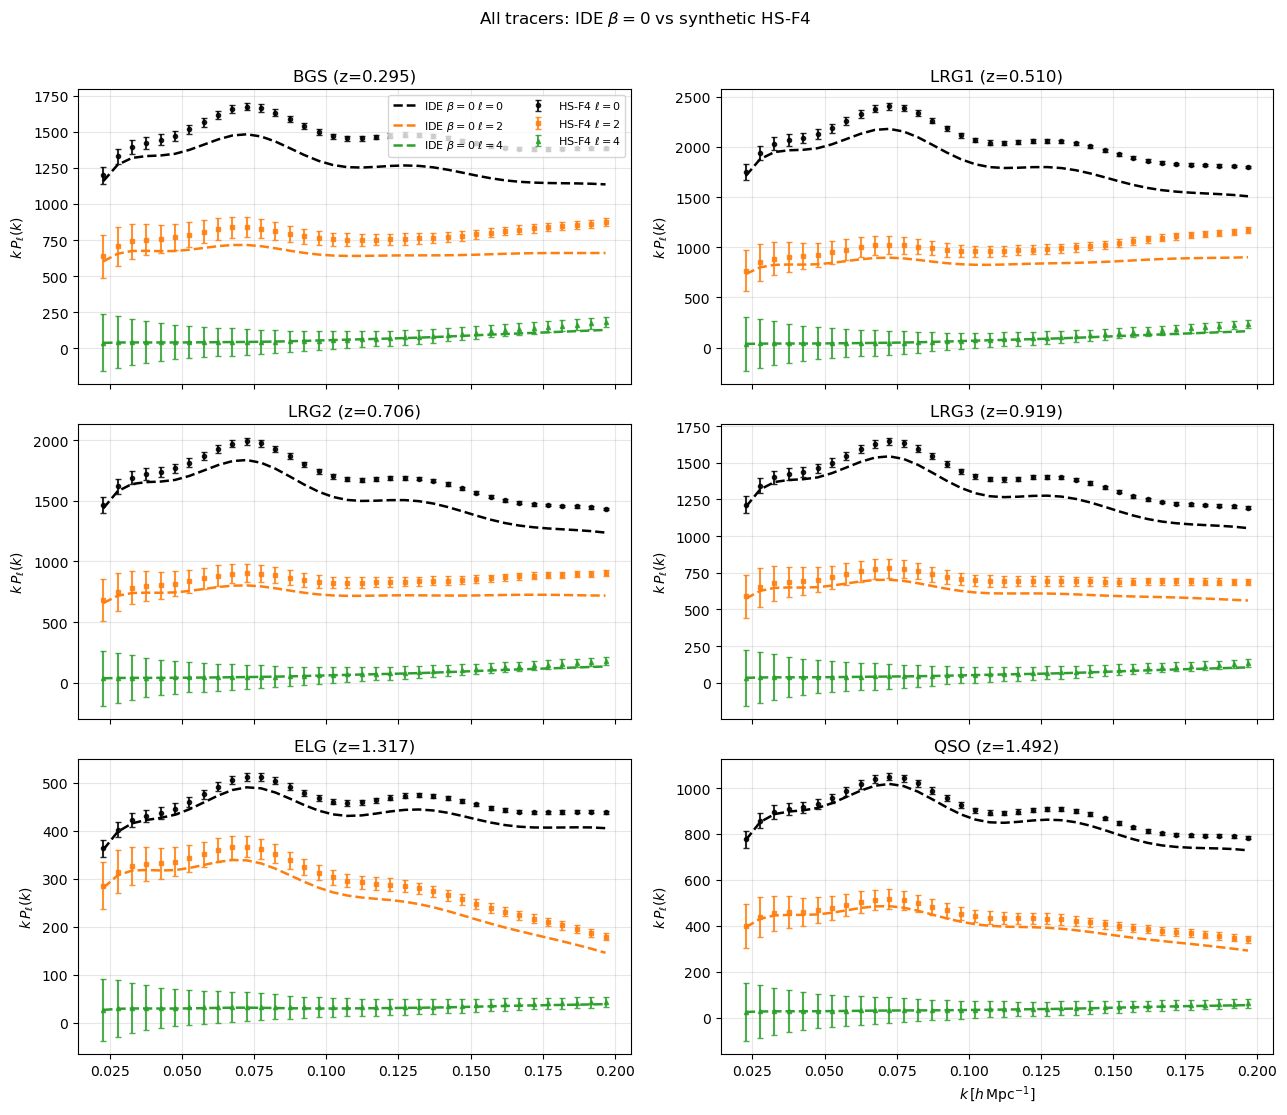

In [18]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '/global/homes/n/nishavk/FOLPSpipe/')
sys.path.insert(0, '/global/homes/n/nishavk/fkptjax_muMG/src/')
sys.path.insert(0, '/global/homes/n/nishavk/isitIDE/')
sys.path.insert(0, '/global/homes/n/nishavk/desilike/')
sys.path.insert(0, '/global/homes/n/nishavk/cosmoprimo/')

# -----------------------------
# Optional JAX settings (debug)
# -----------------------------
os.environ["JAX_DISABLE_JIT"] = "1"
# os.environ.setdefault("JAX_DISABLE_JIT", "1")  # set "0" for speed once validated
import jax
jax.config.update("jax_disable_jit", True)
jax.config.update("jax_enable_x64", True)

# -----------------------------
# desilike / cosmoprimo imports
# -----------------------------
from desilike.theories import Cosmoprimo
from desilike.theories.galaxy_clustering import DirectPowerSpectrumTemplate
from desilike.theories.galaxy_clustering import fkptjaxTracerPowerSpectrumMultipoles
from desilike import parameter
from cosmoprimo.fiducial import DESI

from pathlib import Path

synthetic_data_dir = Path("/global/homes/n/nishavk/desilike/MG/synthetic_data")
k_fixed = np.array([
    0.02271, 0.02768277, 0.03265554, 0.03762831, 0.04260109,
    0.04757386, 0.05254663, 0.05751940, 0.06249217, 0.06746494,
    0.07243771, 0.07741049, 0.08238326, 0.08735603, 0.09232880,
    0.09730157, 0.1022743,  0.1072471,  0.1122199,  0.1171927,
    0.1221654,  0.1271382,  0.1321110,  0.1370837,  0.1420565,
    0.1470293,  0.1520021,  0.1569748,  0.1619476,  0.1669204,
    0.1718931,  0.1768659,  0.1818387,  0.1868115,  0.1917842,
    0.1967570,
])

ells_plot = (0, 2, 4)

# ============================================================
# matching cosmology + EFT settings to the synthetic LCDM data
# ============================================================

IDE_model = "IDE"
ide_variant = "IDEModel1"
beyond_eds = True     # set False for EdS kernels
rescale_PS = False

# ---- nuisance params (STANDARD basis names) ----
freedom = "max"
prior_basis = "standard"   # alias -> standard_folps

b1 = 1.5
b2 = -0.5247206065
bs2 = 0.0
b3nl = 0.0
alpha0, alpha2, alpha4 = 3.0, -1.0, 0.0
ctilde = 0.0
alpha0shot, alpha2shot = 0.08, -2.0
pshotp = 10000.0

# ---- cosmology ----
h      = 0.6736
ombh2  = 0.02237
omch2  = 0.12
omnuh2 = 0.06 / 93.14
Om     = (ombh2 + omch2 + omnuh2) / h**2

As   = 2.083e-09
ns   = 0.9649
Neff = 3.046

Omfid = 0.31519172481908053  # only kept for reference


# Match synthetic-data tracer setup
tracer_settings = {
    "BGS":  {"z_pk": 0.295, "b1": 1.5, "b2": -0.5247206065},
    "LRG1": {"z_pk": 0.51,  "b1": 2.1, "b2": -0.9955559762},
    "LRG2": {"z_pk": 0.706, "b1": 2.1, "b2": -1.129586780},
    "LRG3": {"z_pk": 0.919, "b1": 2.1, "b2": -1.073936223},
    "ELG":  {"z_pk": 1.317, "b1": 1.2, "b2": 0.03376361031},
    "QSO":  {"z_pk": 1.492, "b1": 2.1, "b2": -0.7104953308},
}



def compute_ide_beta0_multipoles_for_tracer(tracer, vals):
    """Compute IDE(beta=0) P0,P2,P4 with fkptjax for one tracer."""
    z = vals["z_pk"]
    b1_local = vals["b1"]
    b2_local = vals["b2"]

    cosmo_local = Cosmoprimo(engine="isitide", dark_energy_model=ide_variant, N_eff=Neff, m_ncdm=[0.06])
    cosmo_local.init.params["h"].update(value=h)
    cosmo_local.init.params["omega_b"].update(value=ombh2)
    cosmo_local.init.params["omega_cdm"].update(value=omch2)
    cosmo_local.init.params["logA"].update(value=float(np.log(1e10 * As)))
    cosmo_local.init.params["n_s"].update(value=ns)

    if "beta" not in cosmo_local.init.params:
        cosmo_local.init.params.data.append(parameter.Parameter(basename="beta", value=0.0, fixed=True))
    cosmo_local.init.params["beta"].update(value=0.0, fixed=True)

    template_local = DirectPowerSpectrumTemplate(z=float(z), fiducial=DESI(), cosmo=cosmo_local)
    template_local.init.update(with_now="peakaverage")

    theory_local = fkptjaxTracerPowerSpectrumMultipoles()
    theory_local.init.update(
        freedom=freedom,
        prior_basis=prior_basis,
        tracer=tracer,
        template=template_local,
        k=k_fixed,
        ells=list(ells_plot),
        model=IDE_model,
        ide_variant=ide_variant,
        beyond_eds=bool(beyond_eds),
        rescale_PS=bool(rescale_PS),
        shotnoise=pshotp,
    )

    fixed_vals_local = {
        "b1": b1_local,
        "b2": b2_local,
        "bs2": 0.0,
        "b3nl": 0.0,
        "alpha0": alpha0,
        "alpha2": alpha2,
        "alpha4": alpha4,
        "ctilde": ctilde,
        "alpha0shot": alpha0shot,
        "alpha2shot": alpha2shot,
    }
    for name, val in fixed_vals_local.items():
        if name in theory_local.init.params:
            theory_local.init.params[name].update(fixed=True, value=float(val))

    P = np.asarray(theory_local())
    if P.ndim == 2:
        P0, P2, P4 = P[0], P[1], P[2]
    elif P.ndim == 1:
        Nk = k_fixed.size
        P0, P2, P4 = P[0 * Nk:1 * Nk], P[1 * Nk:2 * Nk], P[2 * Nk:3 * Nk]
    else:
        raise RuntimeError(f"Unexpected theory output shape {P.shape} for tracer {tracer}")

    return P0, P2, P4


fig, axs = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
axs = axs.flatten()

for i, (tracer, vals) in enumerate(tracer_settings.items()):
    # Compute IDE beta=0 multipoles
    P0_ide, P2_ide, P4_ide = compute_ide_beta0_multipoles_for_tracer(tracer, vals)

    # Load synthetic F4 files
    k_syn = np.loadtxt(synthetic_data_dir / f"{tracer}_F4_k.txt")
    P_syn = np.loadtxt(synthetic_data_dir / f"{tracer}_F4_P0P2P4.txt")
    C_syn = np.loadtxt(synthetic_data_dir / f"{tracer}_F4_cov.txt")

    Nk = k_syn.size
    if P_syn.size != 3 * Nk:
        raise RuntimeError(f"{tracer}: P0P2P4 size mismatch ({P_syn.size} vs {3 * Nk})")
    if C_syn.shape != (3 * Nk, 3 * Nk):
        raise RuntimeError(f"{tracer}: covariance shape mismatch {C_syn.shape}, expected {(3 * Nk, 3 * Nk)}")

    if not np.allclose(k_fixed, k_syn, rtol=0.0, atol=1e-12):
        max_dk = np.max(np.abs(k_fixed - k_syn))
        raise RuntimeError(f"{tracer}: k-grid mismatch (max |dk|={max_dk:.3e})")

    P0_syn = P_syn[0 * Nk:1 * Nk]
    P2_syn = P_syn[1 * Nk:2 * Nk]
    P4_syn = P_syn[2 * Nk:3 * Nk]

    err0 = np.sqrt(np.diag(C_syn[0 * Nk:1 * Nk, 0 * Nk:1 * Nk]))
    err2 = np.sqrt(np.diag(C_syn[1 * Nk:2 * Nk, 1 * Nk:2 * Nk]))
    err4 = np.sqrt(np.diag(C_syn[2 * Nk:3 * Nk, 2 * Nk:3 * Nk]))

    ax = axs[i]

    # Synthetic LCDM with covariance errors
    ax.errorbar(k_syn, k_syn * P0_syn, yerr=k_syn * err0, fmt="o", ms=3, capsize=2,
                color="k", alpha=0.85, label=r"HS-F4 $\ell=0$")
    ax.errorbar(k_syn, k_syn * P2_syn, yerr=k_syn * err2, fmt="s", ms=3, capsize=2,
                color="tab:orange", alpha=0.85, label=r"HS-F4 $\ell=2$")
    ax.errorbar(k_syn, k_syn * P4_syn, yerr=k_syn * err4, fmt="^", ms=3, capsize=2,
                color="tab:green", alpha=0.85, label=r"HS-F4 $\ell=4$")

    # IDE beta=0 curves
    ax.plot(k_fixed, k_fixed * P0_ide, "--", lw=1.8, color="k", label=r"IDE $\beta=0$ $\ell=0$")
    ax.plot(k_fixed, k_fixed * P2_ide, "--", lw=1.8, color="tab:orange", label=r"IDE $\beta=0$ $\ell=2$")
    ax.plot(k_fixed, k_fixed * P4_ide, "--", lw=1.8, color="tab:green", label=r"IDE $\beta=0$ $\ell=4$")

    ax.set_title(f"{tracer} (z={vals['z_pk']:.3f})")
    ax.set_ylabel(r"$k\,P_\ell(k)$")
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(ncols=2, fontsize=8)

axs[-1].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
fig.suptitle("All tracers: IDE $\\beta=0$ vs synthetic HS-F4", y=1.01)
fig.tight_layout()
plt.savefig('./test_plots/IDE_test_with_synthetic_F4.png', dpi=300)
plt.show()


/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarni

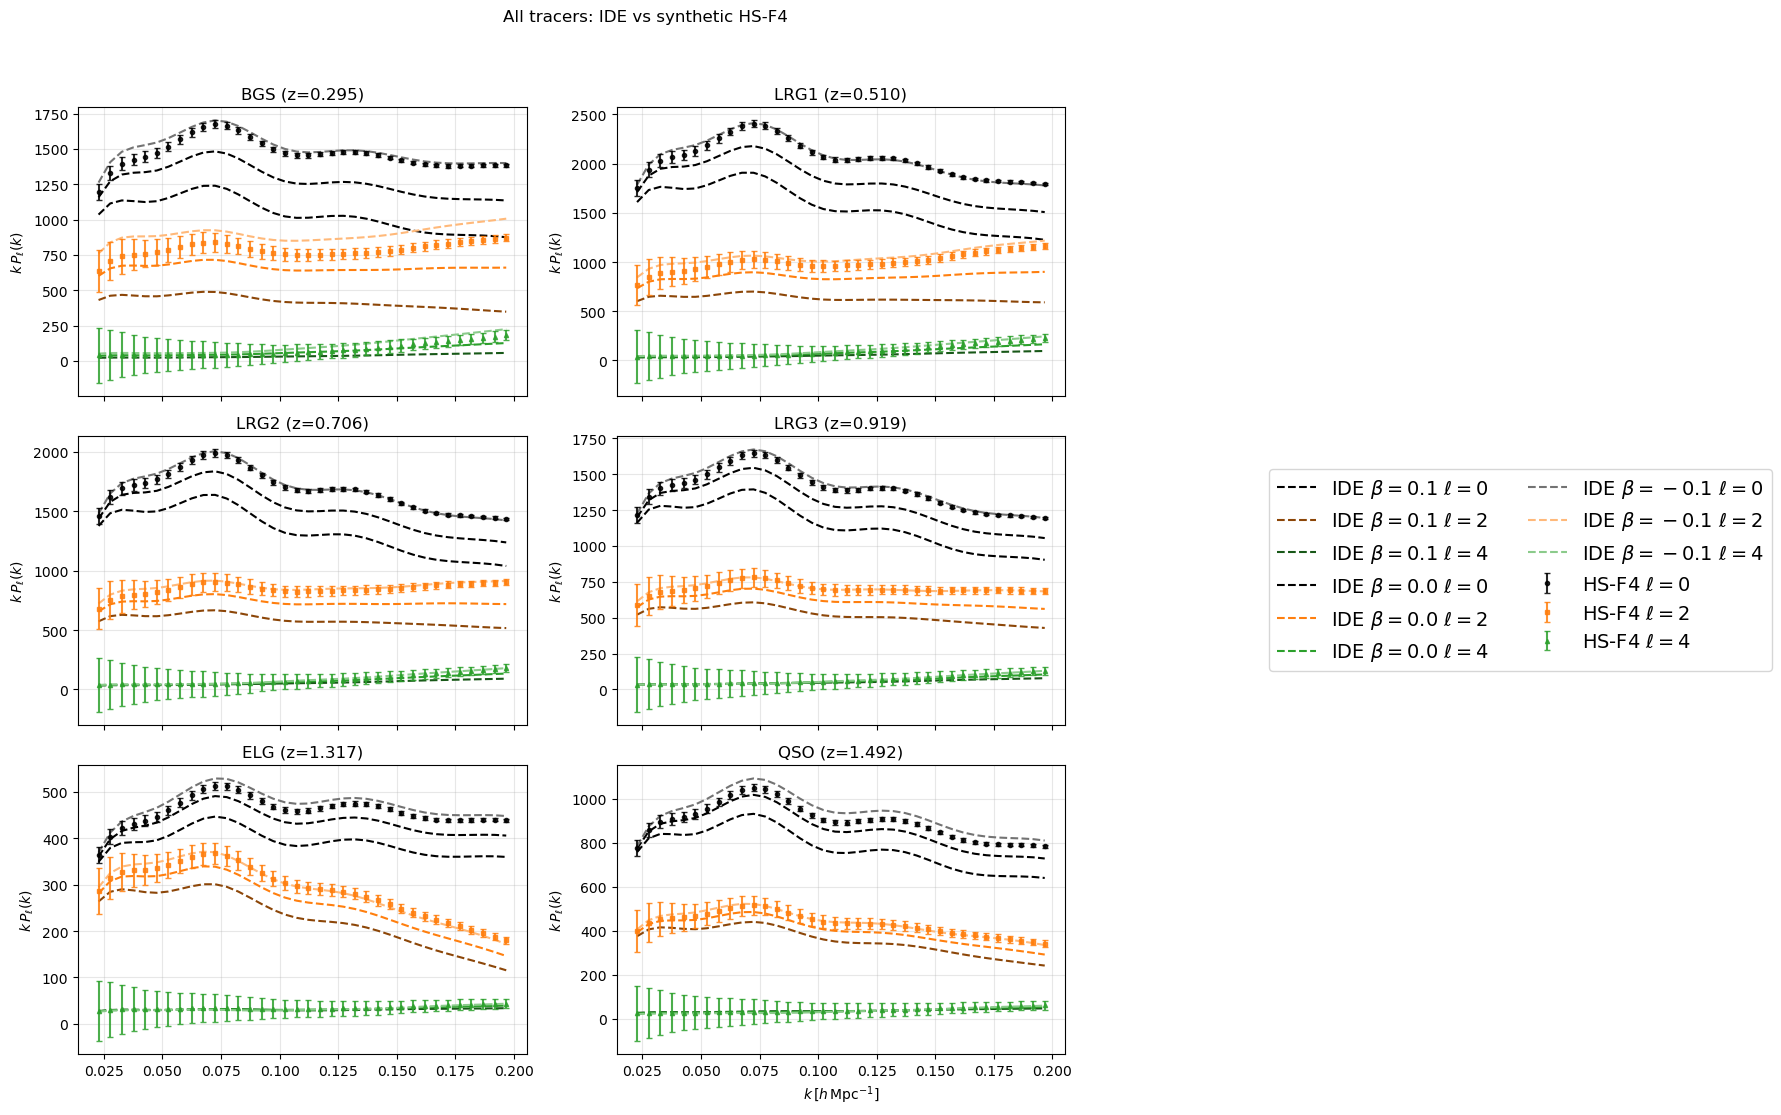

In [20]:
beta_try = [0.1, 0.0, -0.1]

def compute_ide_beta0_multipoles_for_tracer(tracer, vals, beta_try):
    """Compute IDE(beta=beta_try) P0,P2,P4 with fkptjax for one tracer."""
    z = vals["z_pk"]
    b1_local = vals["b1"]
    b2_local = vals["b2"]

    cosmo_local = Cosmoprimo(engine="isitide", dark_energy_model=ide_variant, N_eff=Neff, m_ncdm=[0.06])
    cosmo_local.init.params["h"].update(value=h)
    cosmo_local.init.params["omega_b"].update(value=ombh2)
    cosmo_local.init.params["omega_cdm"].update(value=omch2)
    cosmo_local.init.params["logA"].update(value=float(np.log(1e10 * As)))
    cosmo_local.init.params["n_s"].update(value=ns)

    if "beta" not in cosmo_local.init.params:
        cosmo_local.init.params.data.append(parameter.Parameter(basename="beta", value=beta_try, fixed=True))
    cosmo_local.init.params["beta"].update(value=beta_try, fixed=True)

    template_local = DirectPowerSpectrumTemplate(z=float(z), fiducial=DESI(), cosmo=cosmo_local)
    template_local.init.update(with_now="peakaverage")

    theory_local = fkptjaxTracerPowerSpectrumMultipoles()
    theory_local.init.update(
        freedom=freedom,
        prior_basis=prior_basis,
        tracer=tracer,
        template=template_local,
        k=k_fixed,
        ells=list(ells_plot),
        model=IDE_model,
        ide_variant=ide_variant,
        beyond_eds=bool(beyond_eds),
        rescale_PS=bool(rescale_PS),
        shotnoise=pshotp,
    )

    fixed_vals_local = {
        "b1": b1_local,
        "b2": b2_local,
        "bs2": 0.0,
        "b3nl": 0.0,
        "alpha0": alpha0,
        "alpha2": alpha2,
        "alpha4": alpha4,
        "ctilde": ctilde,
        "alpha0shot": alpha0shot,
        "alpha2shot": alpha2shot,
    }
    for name, val in fixed_vals_local.items():
        if name in theory_local.init.params:
            theory_local.init.params[name].update(fixed=True, value=float(val))

    P = np.asarray(theory_local())
    if P.ndim == 2:
        P0, P2, P4 = P[0], P[1], P[2]
    elif P.ndim == 1:
        Nk = k_fixed.size
        P0, P2, P4 = P[0 * Nk:1 * Nk], P[1 * Nk:2 * Nk], P[2 * Nk:3 * Nk]
    else:
        raise RuntimeError(f"Unexpected theory output shape {P.shape} for tracer {tracer}")

    return P0, P2, P4


fig, axs = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
axs = axs.flatten()

for i, (tracer, vals) in enumerate(tracer_settings.items()):
        
    ax = axs[i]
    
    from matplotlib import colors as mcolors

    def beta_tinted_color(base_color, beta_value, beta_abs_max, tint_strength=0.45):
        rgb = np.array(mcolors.to_rgb(base_color), dtype=float)
        if beta_abs_max <= 0.0 or np.isclose(beta_value, 0.0):
            return tuple(rgb)
        amount = min(abs(float(beta_value)) / beta_abs_max, 1.0) * tint_strength
        if beta_value < 0:
            rgb = rgb + (1.0 - rgb) * amount  # lighten toward white
        else:
            rgb = rgb * (1.0 - amount)        # darken toward black
        return tuple(np.clip(rgb, 0.0, 1.0))

    base_colors = {
        0: "k",           # matches synthetic LCDM ell=0 points
        2: "tab:orange",  # matches synthetic LCDM ell=2 points
        4: "tab:green",   # matches synthetic LCDM ell=4 points
    }
    beta_abs_max = float(np.max(np.abs(np.asarray(beta_try, dtype=float)))) if len(beta_try) else 0.0

    for beta_idx, beta in enumerate(beta_try):
        P0_ide, P2_ide, P4_ide = compute_ide_beta0_multipoles_for_tracer(tracer, vals, beta)

        
        col0 = beta_tinted_color(base_colors[0], beta, beta_abs_max)
        col2 = beta_tinted_color(base_colors[2], beta, beta_abs_max)
        col4 = beta_tinted_color(base_colors[4], beta, beta_abs_max)

        # IDE beta=beta_try curves (colors will be consistent between betas)
        ax.plot(k_fixed, k_fixed * P0_ide, "--", lw=1.5, color=col0,
                label=fr"IDE $\beta={beta}$ $\ell=0$")
        ax.plot(k_fixed, k_fixed * P2_ide, "--", lw=1.5, color=col2,
                label=fr"IDE $\beta={beta}$ $\ell=2$")
        ax.plot(k_fixed, k_fixed * P4_ide, "--", lw=1.5, color=col4,
                label=fr"IDE $\beta={beta}$ $\ell=4$")

    # Load synthetic F4 files
    k_syn = np.loadtxt(synthetic_data_dir / f"{tracer}_F4_k.txt")
    P_syn = np.loadtxt(synthetic_data_dir / f"{tracer}_F4_P0P2P4.txt")
    C_syn = np.loadtxt(synthetic_data_dir / f"{tracer}_F4_cov.txt")

    Nk = k_syn.size
    if P_syn.size != 3 * Nk:
        raise RuntimeError(f"{tracer}: P0P2P4 size mismatch ({P_syn.size} vs {3 * Nk})")
    if C_syn.shape != (3 * Nk, 3 * Nk):
        raise RuntimeError(f"{tracer}: covariance shape mismatch {C_syn.shape}, expected {(3 * Nk, 3 * Nk)}")

    if not np.allclose(k_fixed, k_syn, rtol=0.0, atol=1e-12):
        max_dk = np.max(np.abs(k_fixed - k_syn))
        raise RuntimeError(f"{tracer}: k-grid mismatch (max |dk|={max_dk:.3e})")

    P0_syn = P_syn[0 * Nk:1 * Nk]
    P2_syn = P_syn[1 * Nk:2 * Nk]
    P4_syn = P_syn[2 * Nk:3 * Nk]

    err0 = np.sqrt(np.diag(C_syn[0 * Nk:1 * Nk, 0 * Nk:1 * Nk]))
    err2 = np.sqrt(np.diag(C_syn[1 * Nk:2 * Nk, 1 * Nk:2 * Nk]))
    err4 = np.sqrt(np.diag(C_syn[2 * Nk:3 * Nk, 2 * Nk:3 * Nk]))

    # Synthetic LCDM with covariance errors
    ax.errorbar(k_syn, k_syn * P0_syn, yerr=k_syn * err0, fmt="o", ms=3, capsize=2,
                color="k", alpha=0.85, label=r"HS-F4 $\ell=0$")
    ax.errorbar(k_syn, k_syn * P2_syn, yerr=k_syn * err2, fmt="s", ms=3, capsize=2,
                color="tab:orange", alpha=0.85, label=r"HS-F4 $\ell=2$")
    ax.errorbar(k_syn, k_syn * P4_syn, yerr=k_syn * err4, fmt="^", ms=3, capsize=2,
                color="tab:green", alpha=0.85, label=r"HS-F4 $\ell=4$")

    ax.set_title(f"{tracer} (z={vals['z_pk']:.3f})")
    ax.set_ylabel(r"$k\,P_\ell(k)$")
    ax.grid(alpha=0.3)

axs[-1].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
fig.suptitle(f"All tracers: IDE vs synthetic HS-F4", y=1.01)

# Use a single figure-level legend outside all subplots.
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, ncols=2, fontsize=14, loc="center left", bbox_to_anchor=(0.98, 0.5), borderaxespad=0)

# Leave room on the right for the external legend.
fig.tight_layout(rect=[0.0, 0.0, 0.84, 0.98])
plt.savefig(
    './test_plots/IDE_test_betavary_with_synthetic_F4.png',
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.1,
)
plt.show()
